In [1]:
!pip install zstandard

In [2]:
pip show zstandard

Name: zstandard
Version: 0.23.0
Summary: Zstandard bindings for Python
Home-page: https://github.com/indygreg/python-zstandard
Author: Gregory Szorc
Author-email: gregory.szorc@gmail.com
License: BSD
Location: /home/ec2-user/dynamic_moe/.venv/lib/python3.9/site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [7]:
!pip install transformers datasets torch tqdm matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 227.6 MB/s eta 0:00:00


In [4]:
!mkdir -p ./data
from transformers import AutoTokenizer
from datasets import load_dataset, Dataset
from tqdm import tqdm
import time
import logging
logging.basicConfig(level=logging.WARNING)

# Function to load and collect a fixed number of examples with retries
def get_slimpajama_data(num_train=10000, num_eval=1000, max_retries=5, delay=2):
    def collect_examples(stream, num_examples, split_name):
        examples = []
        iterator = iter(stream)
        pbar = tqdm(total=num_examples, desc=f"Collecting {split_name} examples")
        while len(examples) < num_examples:
            try:
                example = next(iterator)
                examples.append(example)
                pbar.update(1)
            except StopIteration:
                logging.warning(f"Reached end of stream before collecting {num_examples} examples.")
                break
            except Exception as e:
                logging.warning(f"Error while collecting {split_name} example {len(examples)}: {e}")
                retries = 0
                while retries < max_retries:
                    try:
                        time.sleep(delay)
                        example = next(iterator)
                        examples.append(example)
                        pbar.update(1)
                        break
                    except Exception as e_retry:
                        retries += 1
                        logging.warning(f"Retry {retries}/{max_retries} failed: {e_retry}")
                else:
                    logging.warning(f"Skipping {split_name} example after {max_retries} retries.")
        pbar.close()
        return examples

    print(f"Loading {num_train} training examples and {num_eval} evaluation examples...")

    train_stream = load_dataset("cerebras/SlimPajama-627B", split="train", streaming=True)
    eval_stream = load_dataset("cerebras/SlimPajama-627B", split="validation", streaming=True)

    train_examples = collect_examples(train_stream, num_train, "training")
    eval_examples = collect_examples(eval_stream, num_eval, "evaluation")

    train_dataset = Dataset.from_dict({
        'text': [example['text'] for example in train_examples]
    })

    eval_dataset = Dataset.from_dict({
        'text': [example['text'] for example in eval_examples]
    })

    return train_dataset, eval_dataset

# Load and preprocess the data
print("Loading train and evaluation datasets...")
train_dataset, eval_dataset = get_slimpajama_data(num_train=10000, num_eval=1000)


/home/ec2-user/dynamic_moe/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading train and evaluation datasets...
Loading 10000 training examples and 1000 evaluation examples...


In [16]:
from evaluation import ModelEvaluator

evaluator = ModelEvaluator(
    models={
        "Top-K Model": "stevensu123/gpt2-moe-topk",
        "Top-P Model": "stevensu123/gpt2-moe-topp",
        "GPT2-Large Baseline": "gpt2-large"
    },
    dataset=eval_dataset,
    max_length=512,
    batch_size=8
)

In [17]:
results = evaluator.evaluate_all()

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at stevensu123/gpt2-moe-topk and are newly initialized: ['transformer.h.0.mlp.c_fc.bias', 'transformer.h.0.mlp.c_fc.weight', 'transformer.h.0.mlp.c_proj.bias', 'transformer.h.0.mlp.c_proj.weight', 'transformer.h.12.mlp.c_fc.bias', 'transformer.h.12.mlp.c_fc.weight', 'transformer.h.12.mlp.c_proj.bias', 'transformer.h.12.mlp.c_proj.weight', 'transformer.h.16.mlp.c_fc.bias', 'transformer.h.16.mlp.c_fc.weight', 'transformer.h.16.mlp.c_proj.bias', 'transformer.h.16.mlp.c_proj.weight', 'transformer.h.20.mlp.c_fc.bias', 'transformer.h.20.mlp.c_fc.weight', 'transformer.h.20.mlp.c_proj.bias', 'transformer.h.20.mlp.c_proj.weight', 'transformer.h.24.mlp.c_fc.bias', 'transformer.h.24.mlp.c_fc.weight', 'transformer.h.24.mlp.c_proj.bias', 'transformer.h.24.mlp.c_proj.weight', 'transformer.h.28.mlp.c_fc.bias', 'transformer.h.28.mlp.c_fc.weight', 'transformer.h.28.mlp.c_proj.bias', 'transformer.h.28.mlp.c_proj.weight', 'tra

KeyboardInterrupt: 


Accuracy & Performance
Model                | token_accuracy 
--------------------------------------
Top-K Model          | 0.0000         
Top-P Model          | 0.0000         
GPT2-Large Baseline  | 0.0000         

Efficiency

Adaptive Behavior


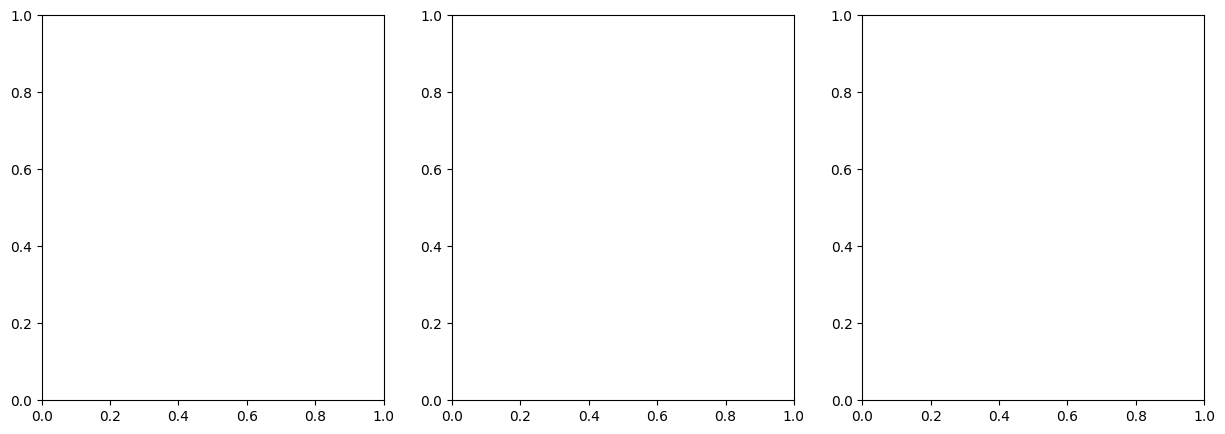

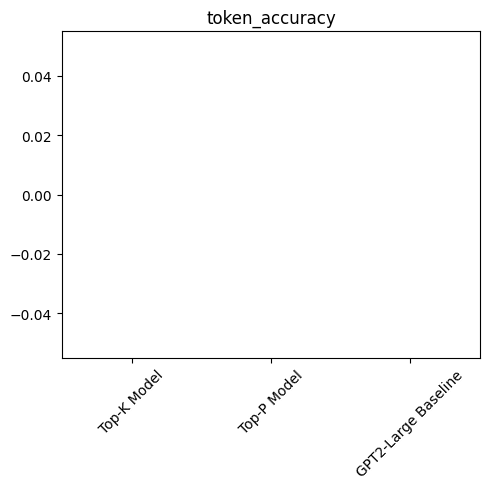

<Figure size 640x480 with 0 Axes>

In [15]:
evaluator.print_results()  # Prints formatted table
evaluator.plot_results()   # Shows plots